# The Perceptron

The simplest neural network: **one neuron**.

We'll train it the same way we train big networks -- forward pass, compute loss, update weights.

1. What is a perceptron?
2. Train it to learn AND, OR, NOT, NAND
3. Watch it fail on XOR
4. Visualize decision surfaces

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

C0, C1 = '#e85a4f', '#2a9d8f'
print('Ready!')
%config InlineBackend.figure_format = 'retina'

Ready!


## What is a Perceptron?

$$y = \text{activation}(w_1 x_1 + w_2 x_2 + b)$$

- Takes inputs $x_1, x_2$
- Multiplies by weights $w_1, w_2$
- Adds bias $b$
- Passes through an **activation function**

### Classic vs Modern Perceptron

The **original perceptron** (Rosenblatt, 1958) used a **step function**:

$$\text{step}(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{otherwise} \end{cases}$$

But step functions have zero gradient -- we can't use gradient descent to train them!

**Modern approach:** use **sigmoid** $\sigma(z) = \frac{1}{1+e^{-z}}$ -- smooth version of step, trainable with gradient descent.

Either way, one neuron = one straight decision boundary.

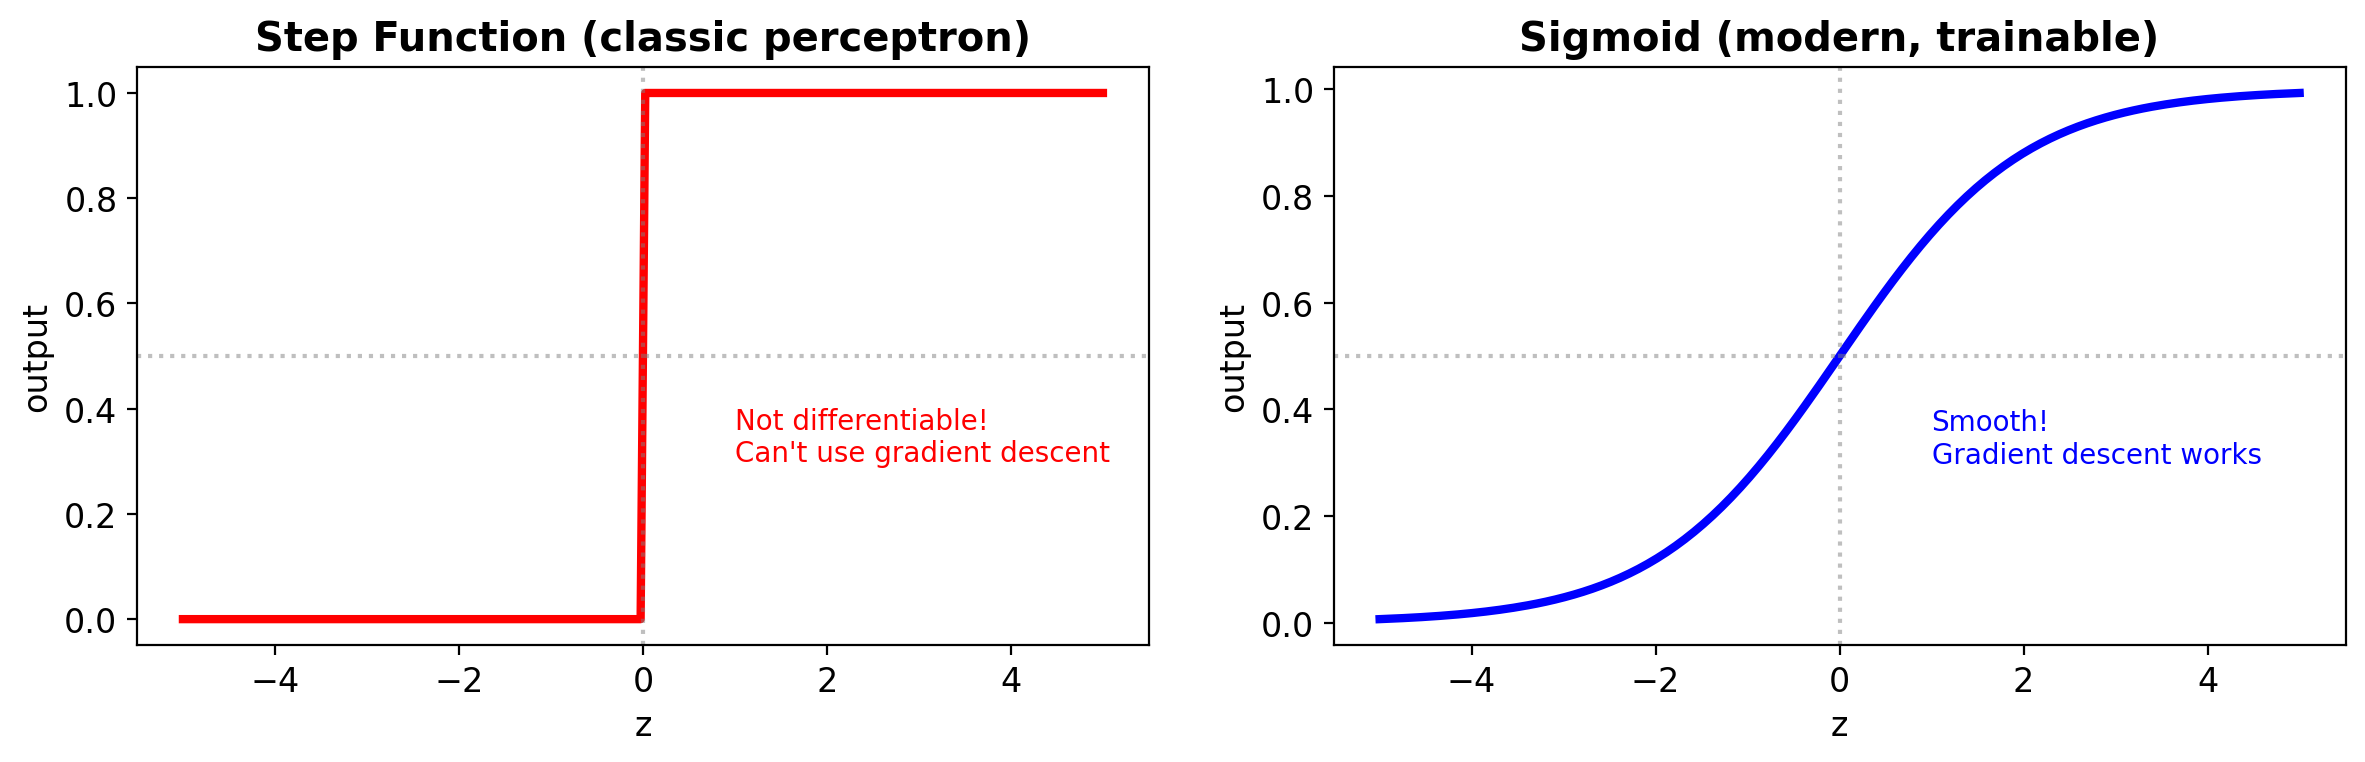

We use sigmoid so we can train with gradient descent.
The decision boundary (where output = 0.5) is the same: a straight line.


In [25]:
# Visualize: step vs sigmoid
z = np.linspace(-5, 5, 200)
step = (z > 0).astype(float)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, step, 'r-', linewidth=3)
axes[0].set_title('Step Function (classic perceptron)', fontweight='bold')
axes[0].set_xlabel('z'); axes[0].set_ylabel('output')
axes[0].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].text(1, 0.3, 'Not differentiable!\nCan\'t use gradient descent', fontsize=10, color='red')

axes[1].plot(z, sigmoid, 'b-', linewidth=3)
axes[1].set_title('Sigmoid (modern, trainable)', fontweight='bold')
axes[1].set_xlabel('z'); axes[1].set_ylabel('output')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[1].text(1, 0.3, 'Smooth!\nGradient descent works', fontsize=10, color='blue')

plt.tight_layout()
plt.show()

print('We use sigmoid so we can train with gradient descent.')
print('The decision boundary (where output = 0.5) is the same: a straight line.')

In [26]:
class Perceptron(nn.Module):
    """A single neuron with sigmoid activation."""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        return self.sigmoid(self.linear(x))

print('Perceptron = Linear(2, 1) + Sigmoid')
p = Perceptron()
print(f'Parameters: w1, w2, b = {p.linear.weight.data.numpy().ravel()}, {p.linear.bias.data.item():.4f}')
print(f'Total parameters: {sum(p.numel() for p in p.parameters())} (2 weights + 1 bias)')

Perceptron = Linear(2, 1) + Sigmoid
Parameters: w1, w2, b = [-0.655962   -0.44515052], -0.1790
Total parameters: 3 (2 weights + 1 bias)


## Training a Perceptron on Logic Gates

Logic gates are the simplest classification problems: 4 data points, 2 classes.

In [27]:
# All logic gate datasets
X_gate = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)

gates = {
    'AND':  torch.tensor([[0], [0], [0], [1]], dtype=torch.float32),
    'OR':   torch.tensor([[0], [1], [1], [1]], dtype=torch.float32),
    'NAND': torch.tensor([[1], [1], [1], [0]], dtype=torch.float32),
    'XOR':  torch.tensor([[0], [1], [1], [0]], dtype=torch.float32),
}

# Show truth tables
print(f'{"x1":>3} {"x2":>3}  |  {"AND":>4} {"OR":>4} {"NAND":>5} {"XOR":>4}')
print('-' * 42)
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    vals = [int(gates[g][i].item()) for g in ['AND', 'OR', 'NAND', 'XOR']]
    print(f'{x1:>3} {x2:>3}  |  {vals[0]:>4} {vals[1]:>4} {vals[2]:>5} {vals[3]:>4}')

 x1  x2  |   AND   OR  NAND  XOR
------------------------------------------
  0   0  |     0    0     1    0
  0   1  |     0    1     1    1
  1   0  |     0    1     1    1
  1   1  |     1    1     0    0


In [28]:
def train_perceptron(X, y, epochs=2000, lr=0.5, seed=42):
    """Train a perceptron and return model + training history."""
    torch.manual_seed(seed)
    model = Perceptron()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    
    history = {'loss': [], 'weights': [], 'predictions': []}
    
    for epoch in range(epochs):
        pred = model(X)
        loss = loss_fn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        history['loss'].append(loss.item())
        w = model.linear.weight.data.clone().numpy().ravel()
        b = model.linear.bias.data.clone().item()
        history['weights'].append((w[0], w[1], b))
        history['predictions'].append(pred.detach().numpy().ravel().copy())
    
    return model, history

In [29]:
def plot_decision_surface(model, X, y, title='', ax=None):
    """Plot the decision surface of a perceptron."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    # Create mesh
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                         np.linspace(-0.5, 1.5, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
    
    # Probability heatmap
    im = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.6, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    # Data points
    y_np = y.numpy().ravel()
    ax.scatter(X[y_np == 0, 0], X[y_np == 0, 1], c=C0, s=200, edgecolors='black', 
               linewidth=2, zorder=5, label='0')
    ax.scatter(X[y_np == 1, 0], X[y_np == 1, 1], c=C1, s=200, edgecolors='black',
               linewidth=2, zorder=5, label='1')
    
    # Labels on points
    for i in range(len(X)):
        ax.annotate(f'{int(y_np[i])}', (X[i, 0].item(), X[i, 1].item()),
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if y_np[i] == 0 else 'white')
    
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_aspect('equal')
    return ax


def plot_learning(history, gate_name, y):
    """Plot loss curve and prediction evolution."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history['loss'], color='#1e3a5f', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{gate_name} -- Training Loss', fontweight='bold')
    
    # Predictions over time
    preds = np.array(history['predictions'])
    labels = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
    colors_line = ['#e85a4f', '#2a9d8f', '#e76f51', '#264653']
    for i in range(4):
        axes[1].plot(preds[:, i], label=labels[i], linewidth=2, color=colors_line[i])
    
    # Target lines
    y_np = y.numpy().ravel()
    for i in range(4):
        axes[1].axhline(y=y_np[i], color=colors_line[i], linestyle=':', alpha=0.3)
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Prediction')
    axes[1].set_title(f'{gate_name} -- Predictions Over Time', fontweight='bold')
    axes[1].legend(loc='center right')
    axes[1].set_ylim(-0.05, 1.05)
    
    plt.tight_layout()
    plt.show()

## Learning the AND Gate

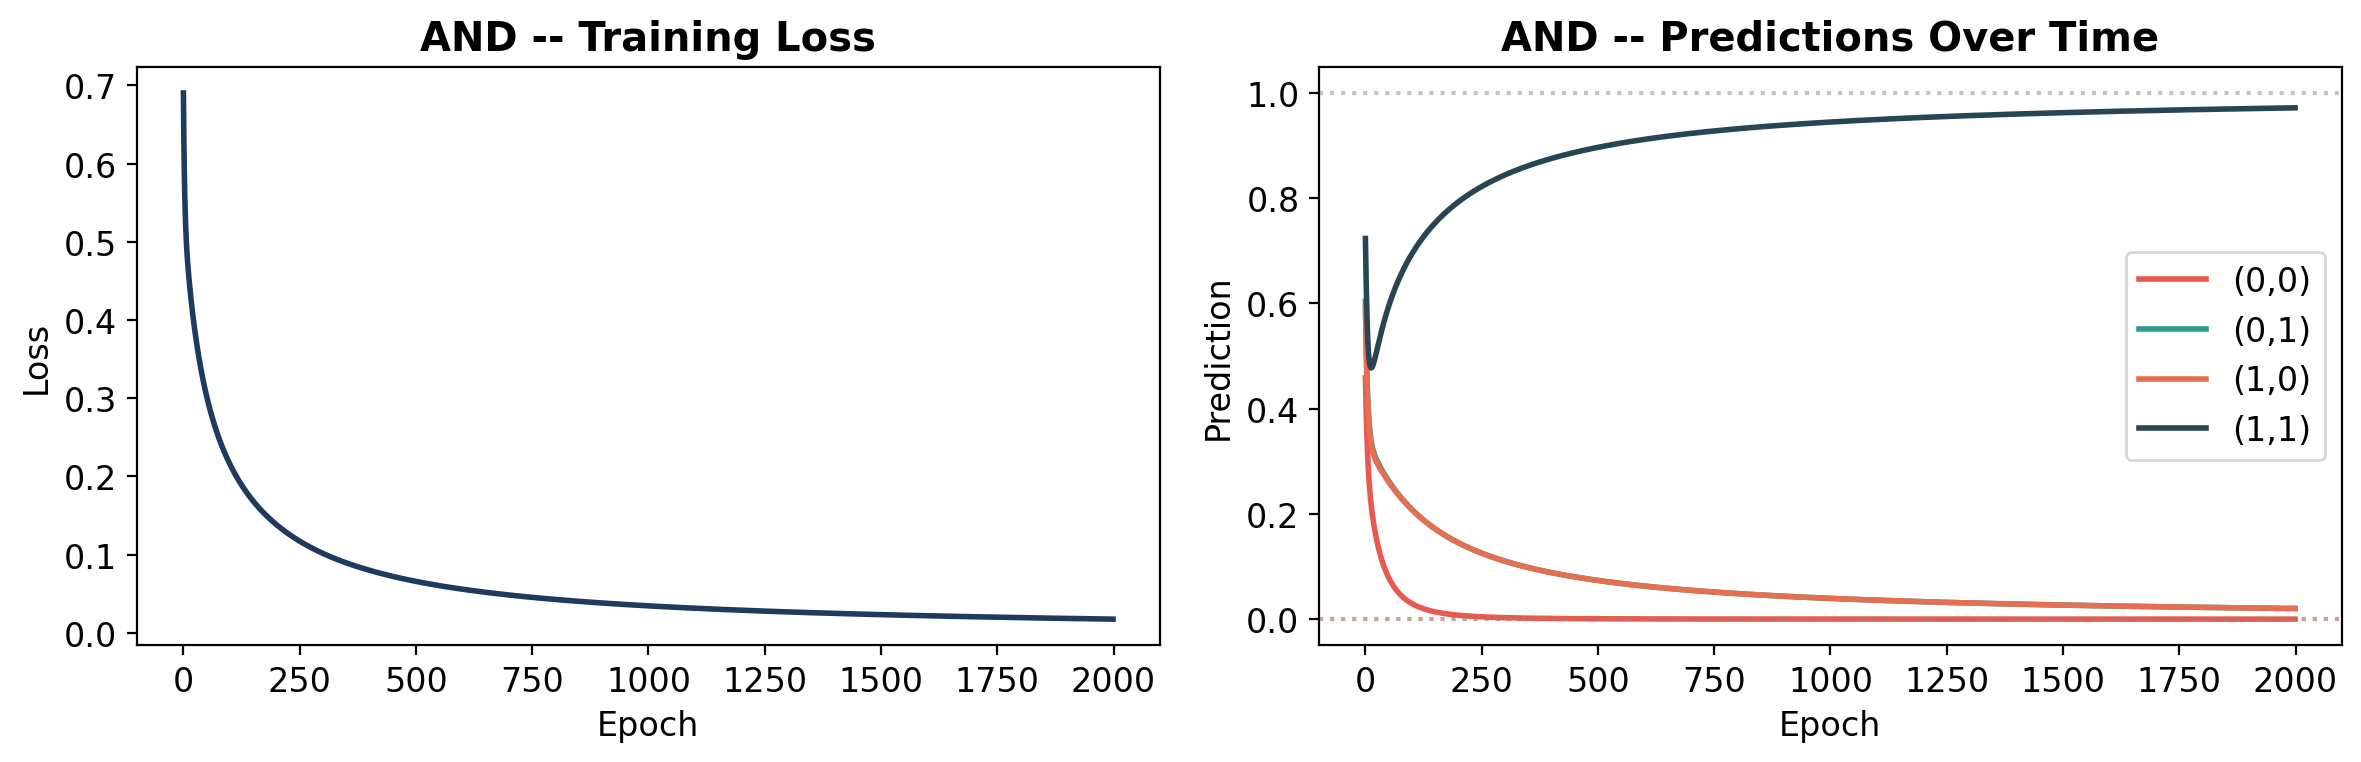

Final predictions:
  0 AND 0 = 0.000 (round to 0) -- target: 0
  0 AND 1 = 0.020 (round to 0) -- target: 0
  1 AND 0 = 0.020 (round to 0) -- target: 0
  1 AND 1 = 0.972 (round to 1) -- target: 1


In [30]:
model_and, hist_and = train_perceptron(X_gate, gates['AND'])

# Show results
plot_learning(hist_and, 'AND', gates['AND'])

# Final predictions
with torch.no_grad():
    preds = model_and(X_gate)
print('Final predictions:')
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    p = preds[i].item()
    target = int(gates['AND'][i].item())
    print(f'  {x1} AND {x2} = {p:.3f} (round to {round(p)}) -- target: {target}')

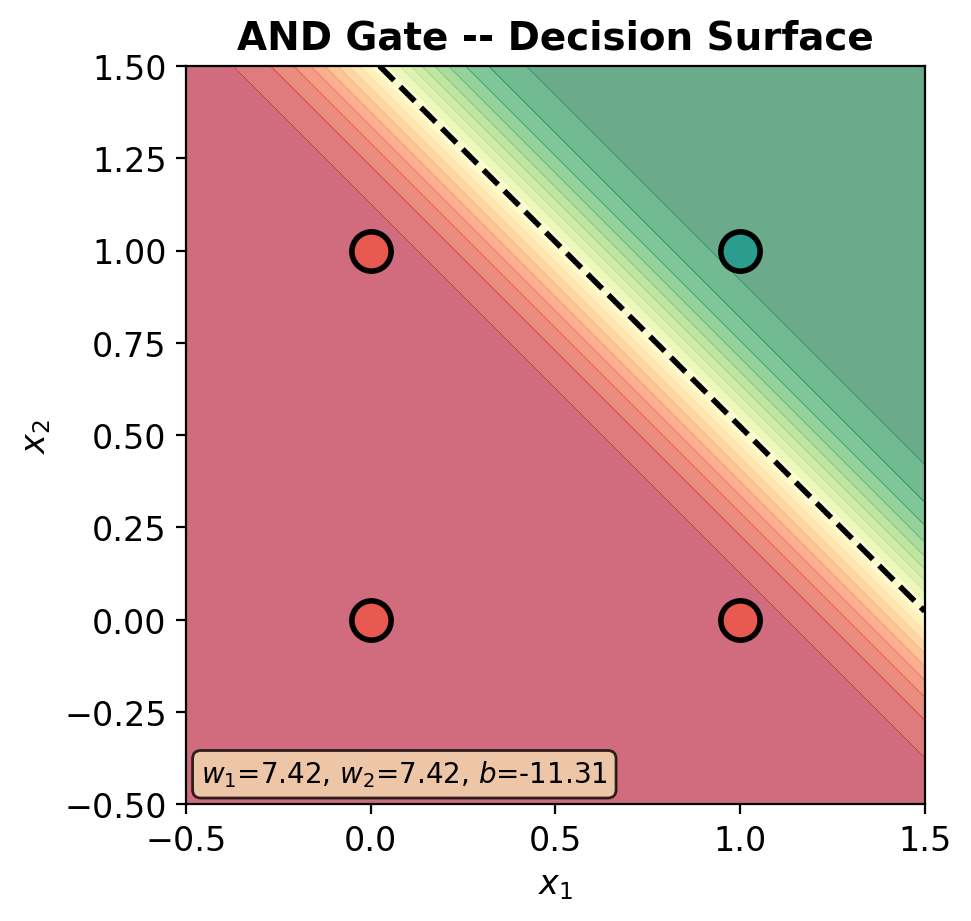

Decision boundary: 7.42*x1 + 7.42*x2 + -11.31 = 0
The line separates (1,1) from everything else.


In [31]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_surface(model_and, X_gate.numpy(), gates['AND'], 'AND Gate -- Decision Surface', ax=ax)

# Show learned weights
w1, w2 = model_and.linear.weight.data.numpy().ravel()
b = model_and.linear.bias.data.item()
ax.text(0.02, 0.02, f'$w_1$={w1:.2f}, $w_2$={w2:.2f}, $b$={b:.2f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

print(f'Decision boundary: {w1:.2f}*x1 + {w2:.2f}*x2 + {b:.2f} = 0')
print('The line separates (1,1) from everything else.')

## Learning the OR Gate

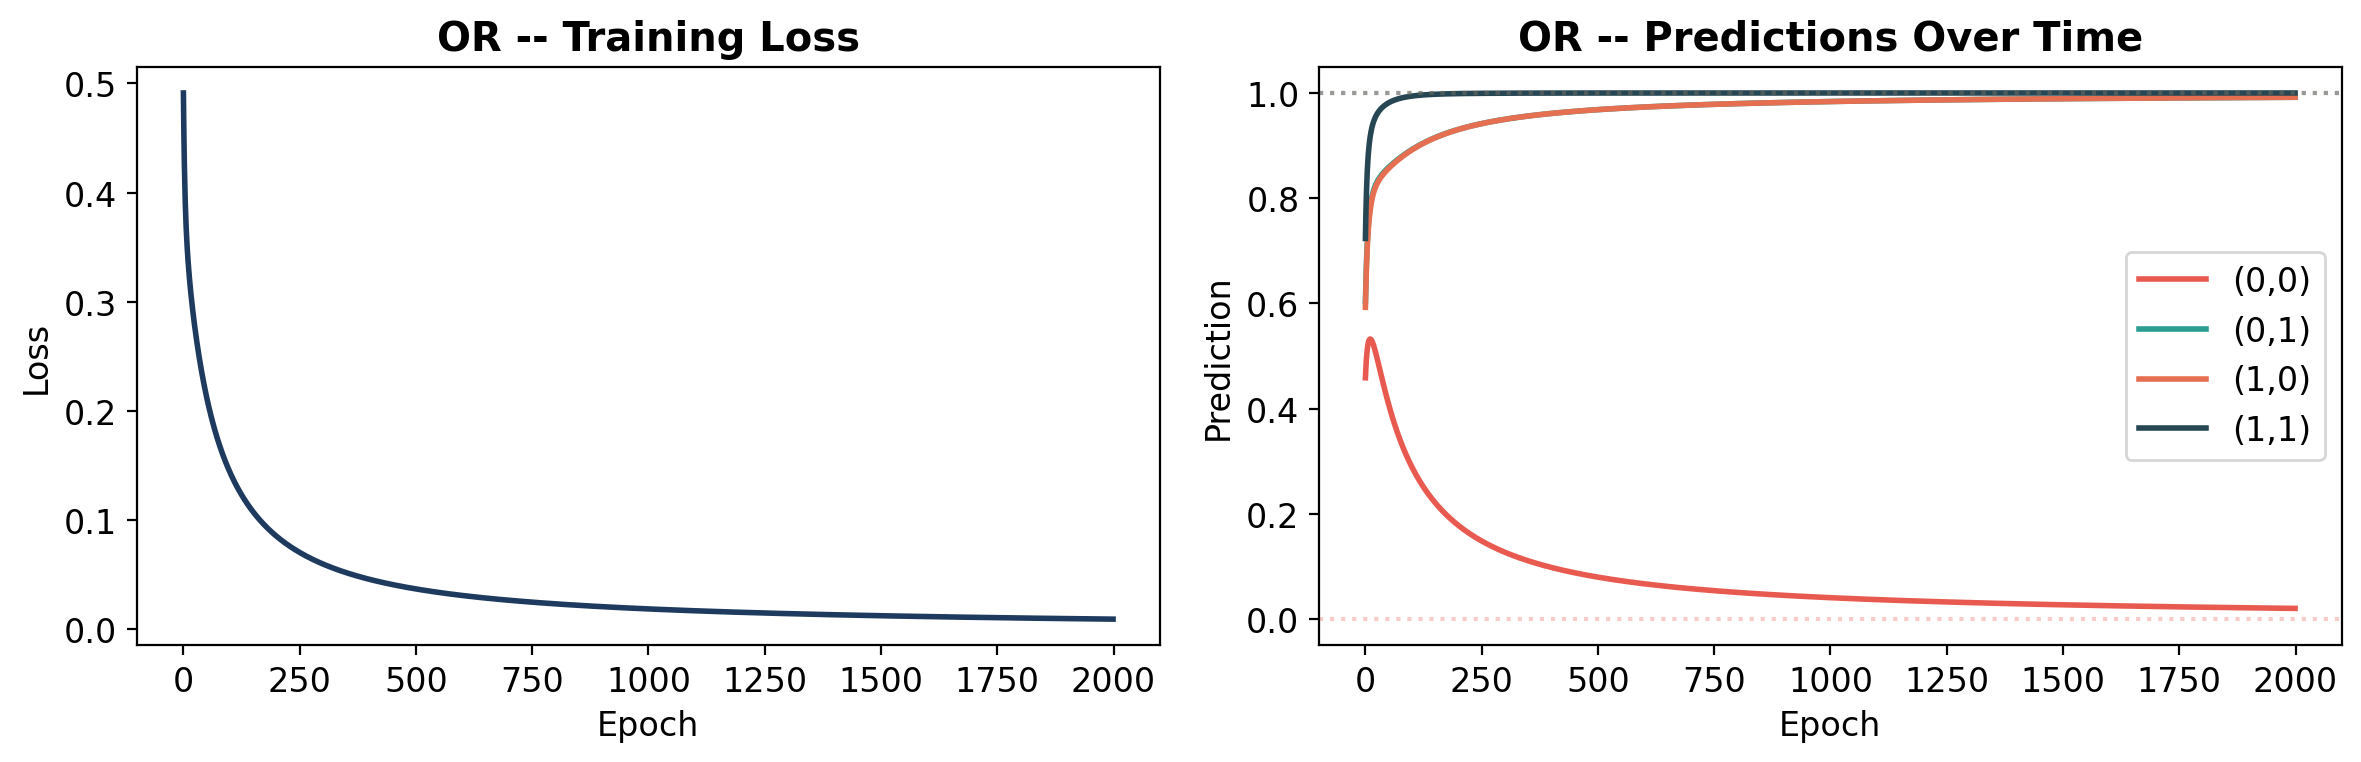

Final predictions:
  0 OR 0 = 0.020 (round to 0) -- target: 0
  0 OR 1 = 0.992 (round to 1) -- target: 1
  1 OR 0 = 0.992 (round to 1) -- target: 1
  1 OR 1 = 1.000 (round to 1) -- target: 1


In [32]:
model_or, hist_or = train_perceptron(X_gate, gates['OR'])
plot_learning(hist_or, 'OR', gates['OR'])

with torch.no_grad():
    preds = model_or(X_gate)
print('Final predictions:')
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    p = preds[i].item()
    print(f'  {x1} OR {x2} = {p:.3f} (round to {round(p)}) -- target: {int(gates["OR"][i].item())}')

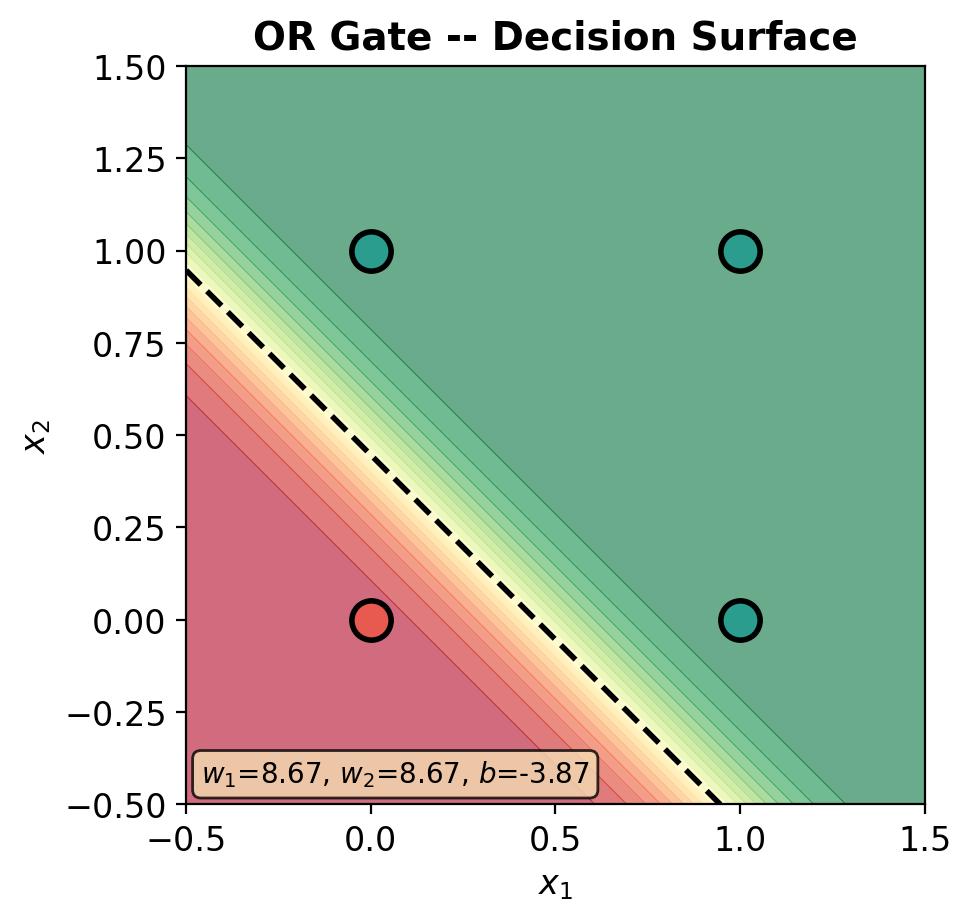

The line separates (0,0) from everything else.


In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_surface(model_or, X_gate.numpy(), gates['OR'], 'OR Gate -- Decision Surface', ax=ax)
w1, w2 = model_or.linear.weight.data.numpy().ravel()
b = model_or.linear.bias.data.item()
ax.text(0.02, 0.02, f'$w_1$={w1:.2f}, $w_2$={w2:.2f}, $b$={b:.2f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

print('The line separates (0,0) from everything else.')

## Learning the NAND Gate

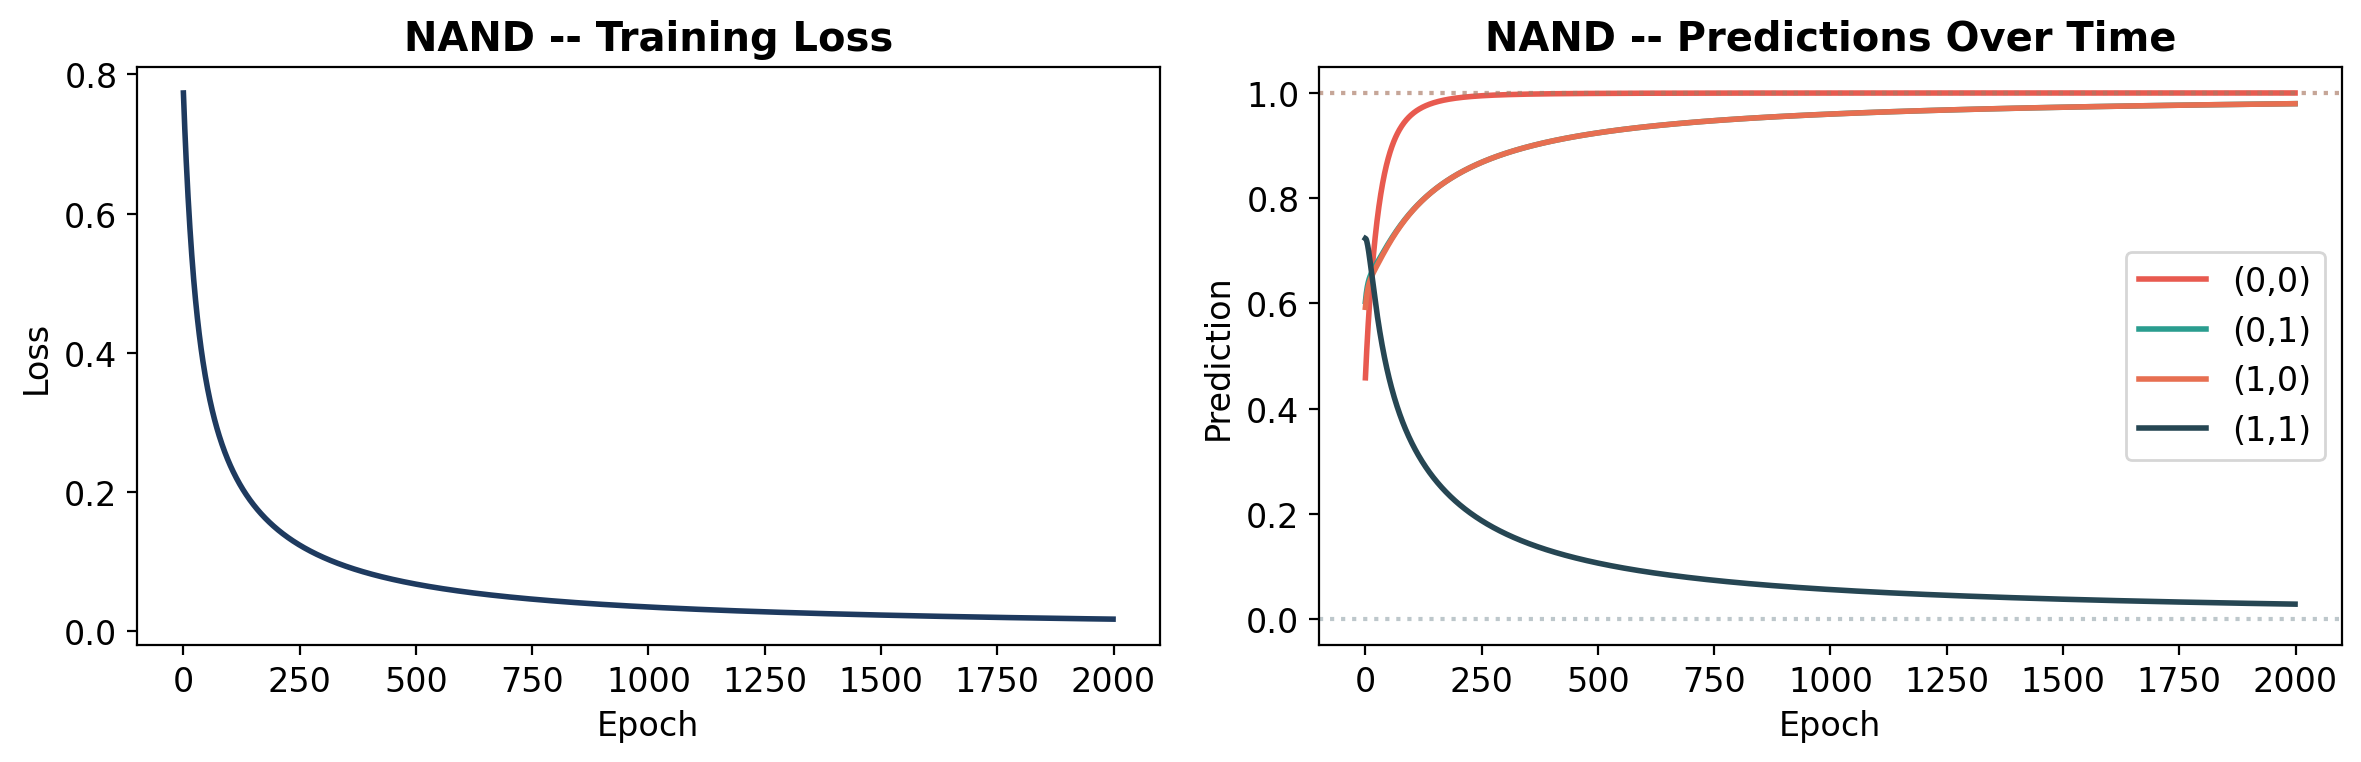

Final predictions:
  0 NAND 0 = 1.000 (round to 1) -- target: 1
  0 NAND 1 = 0.980 (round to 1) -- target: 1
  1 NAND 0 = 0.980 (round to 1) -- target: 1
  1 NAND 1 = 0.028 (round to 0) -- target: 0


In [34]:
model_nand, hist_nand = train_perceptron(X_gate, gates['NAND'])
plot_learning(hist_nand, 'NAND', gates['NAND'])

with torch.no_grad():
    preds = model_nand(X_gate)
print('Final predictions:')
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    p = preds[i].item()
    print(f'  {x1} NAND {x2} = {p:.3f} (round to {round(p)}) -- target: {int(gates["NAND"][i].item())}')

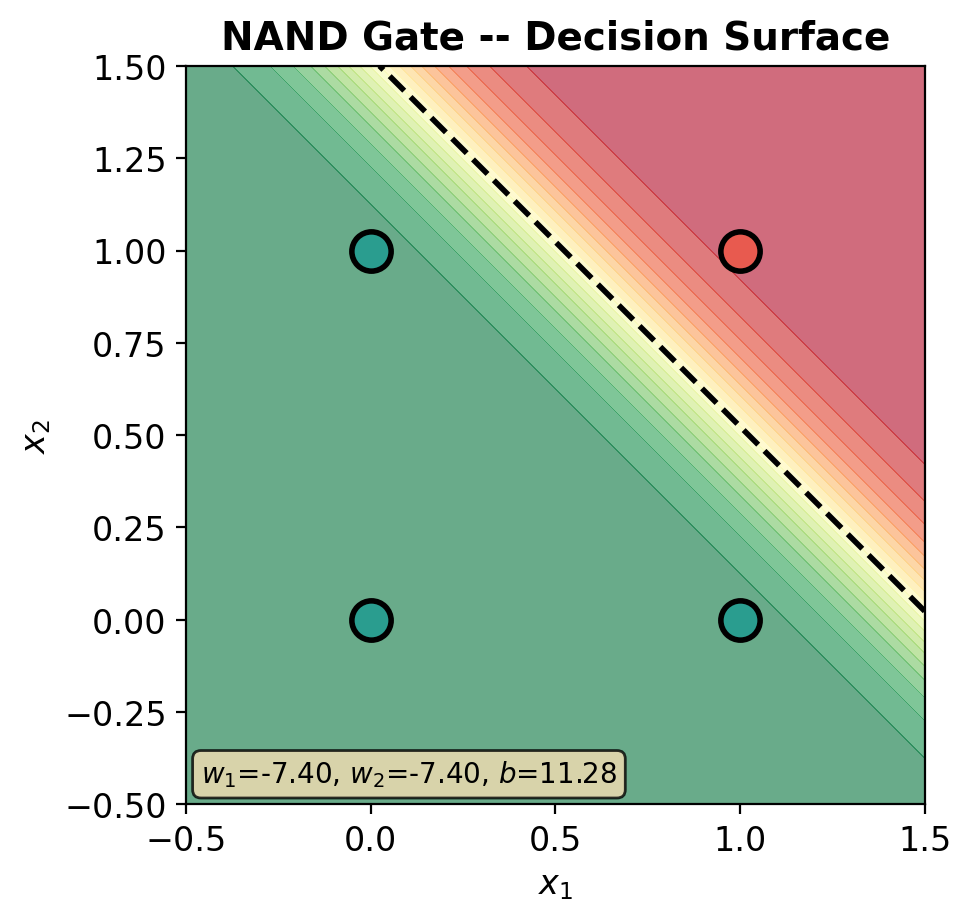

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_surface(model_nand, X_gate.numpy(), gates['NAND'], 'NAND Gate -- Decision Surface', ax=ax)
w1, w2 = model_nand.linear.weight.data.numpy().ravel()
b = model_nand.linear.bias.data.item()
ax.text(0.02, 0.02, f'$w_1$={w1:.2f}, $w_2$={w2:.2f}, $b$={b:.2f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.show()

## All Learnable Gates Side by Side

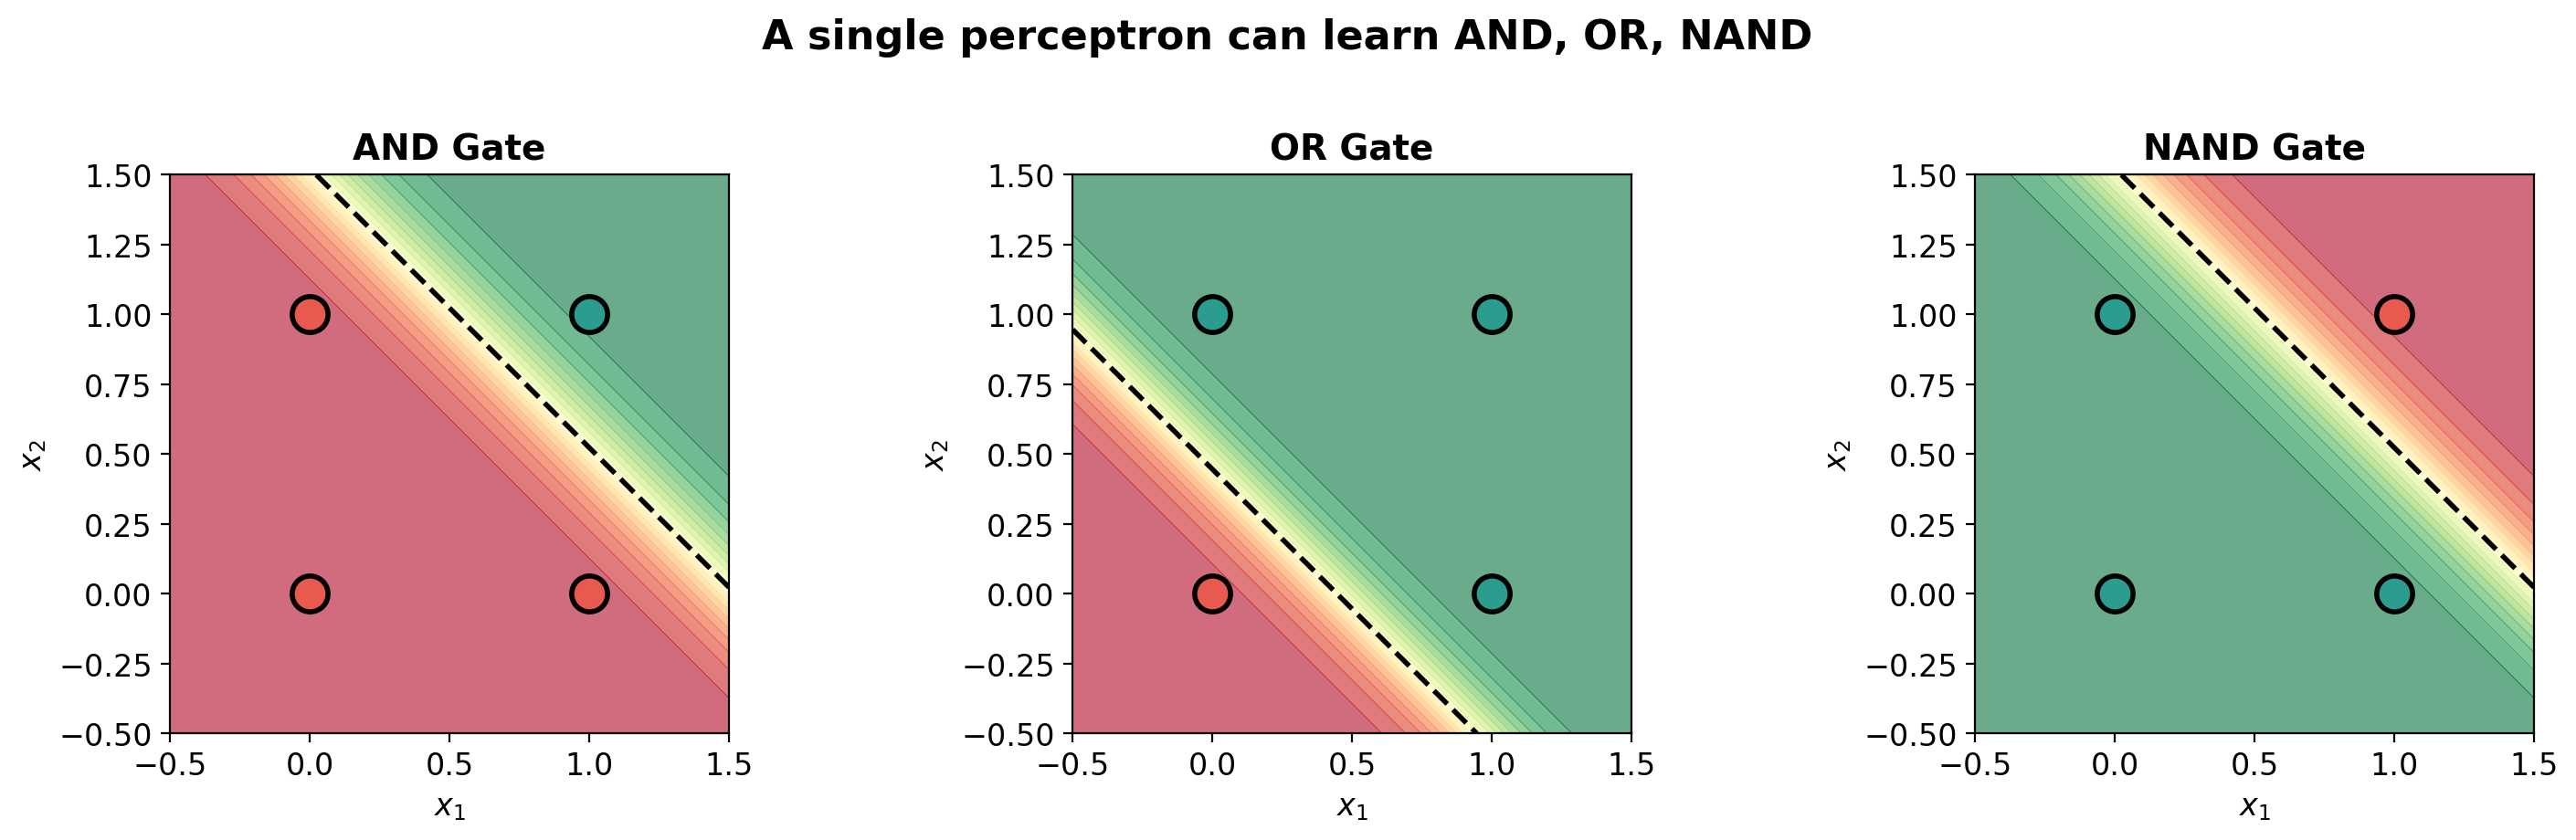

All three gates are linearly separable -- one line does the job.
The perceptron just needs to find the right line.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models = [model_and, model_or, model_nand]
names = ['AND', 'OR', 'NAND']
gate_labels = [gates['AND'], gates['OR'], gates['NAND']]

for ax, model, name, y in zip(axes, models, names, gate_labels):
    plot_decision_surface(model, X_gate.numpy(), y, f'{name} Gate', ax=ax)

plt.suptitle('A single perceptron can learn AND, OR, NAND', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('All three gates are linearly separable -- one line does the job.')
print('The perceptron just needs to find the right line.')

## XOR: The Perceptron's Kryptonite

XOR = 1 when inputs are **different**, 0 when inputs are the **same**.

Can a single line separate (0,1) and (1,0) from (0,0) and (1,1)?

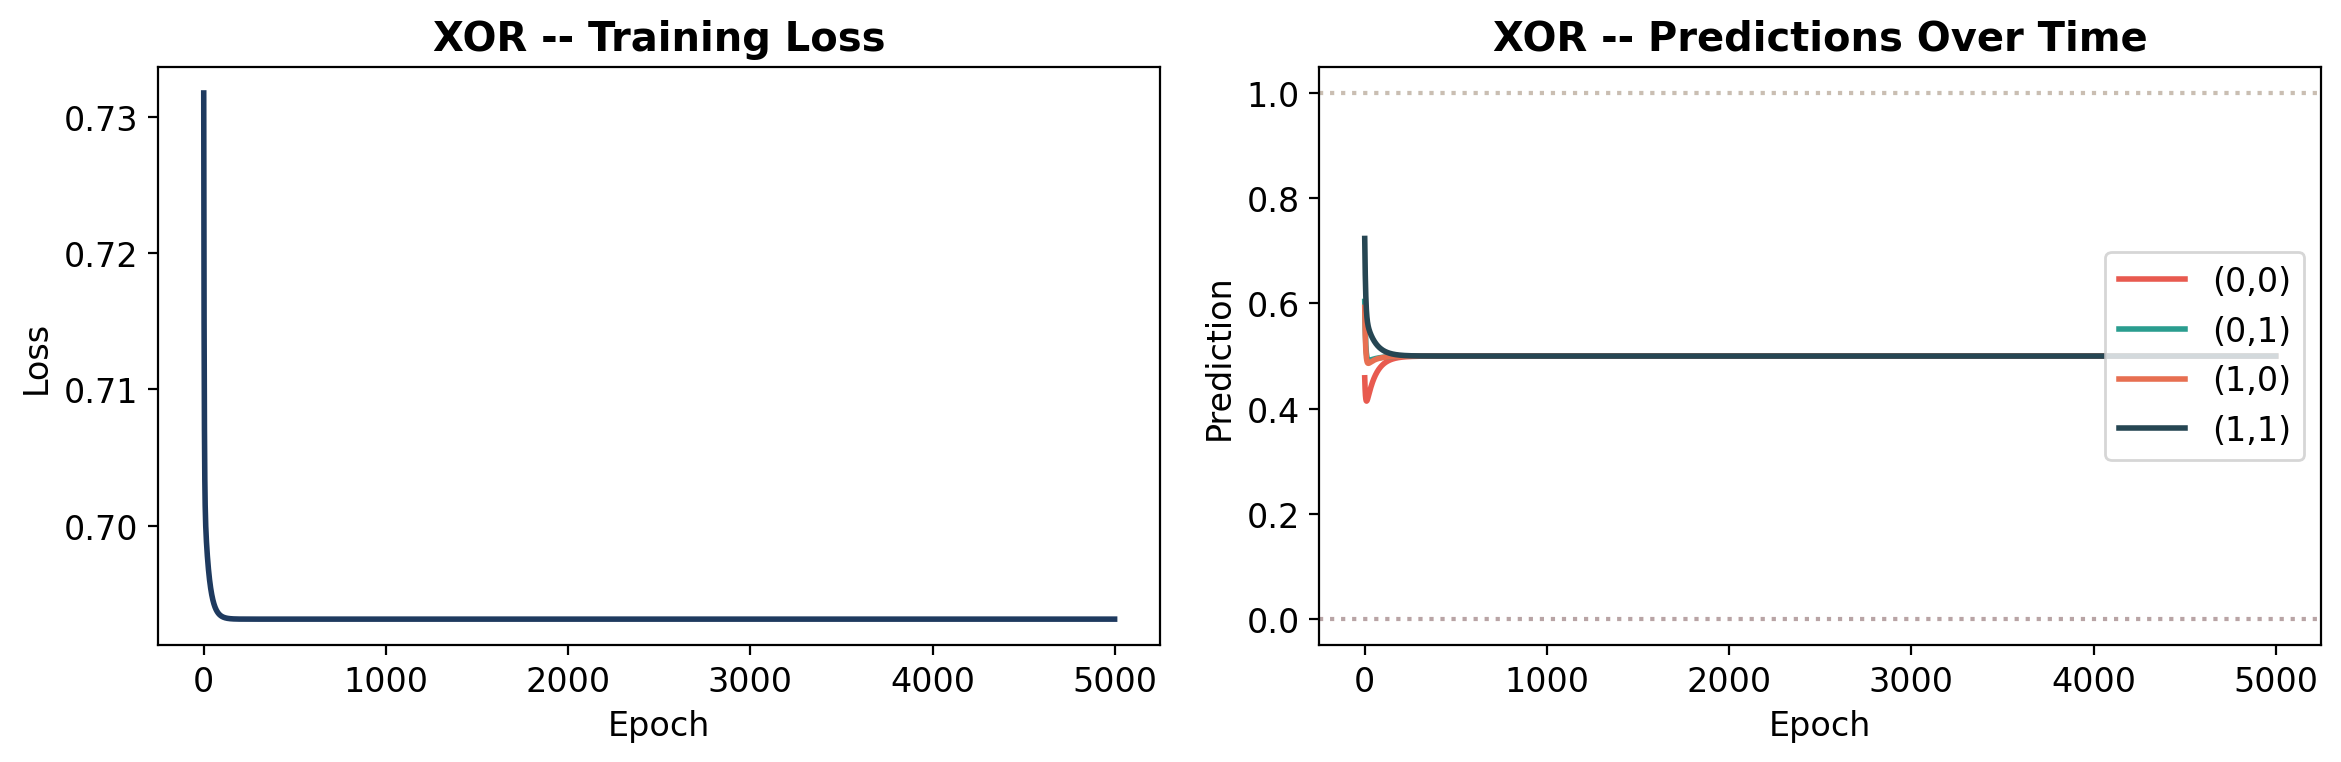

Final predictions:
  0 XOR 0 = 0.500 (round to 0) -- target: 0  OK
  0 XOR 1 = 0.500 (round to 0) -- target: 1  WRONG
  1 XOR 0 = 0.500 (round to 0) -- target: 1  WRONG
  1 XOR 1 = 0.500 (round to 0) -- target: 0  OK

Accuracy: 2/4
The perceptron CANNOT learn XOR!


In [37]:
model_xor, hist_xor = train_perceptron(X_gate, gates['XOR'], epochs=5000)
plot_learning(hist_xor, 'XOR', gates['XOR'])

with torch.no_grad():
    preds = model_xor(X_gate)

print('Final predictions:')
correct = 0
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    p = preds[i].item()
    target = int(gates['XOR'][i].item())
    match = 'OK' if round(p) == target else 'WRONG'
    if round(p) == target: correct += 1
    print(f'  {x1} XOR {x2} = {p:.3f} (round to {round(p)}) -- target: {target}  {match}')

print(f'\nAccuracy: {correct}/4')
print('The perceptron CANNOT learn XOR!')

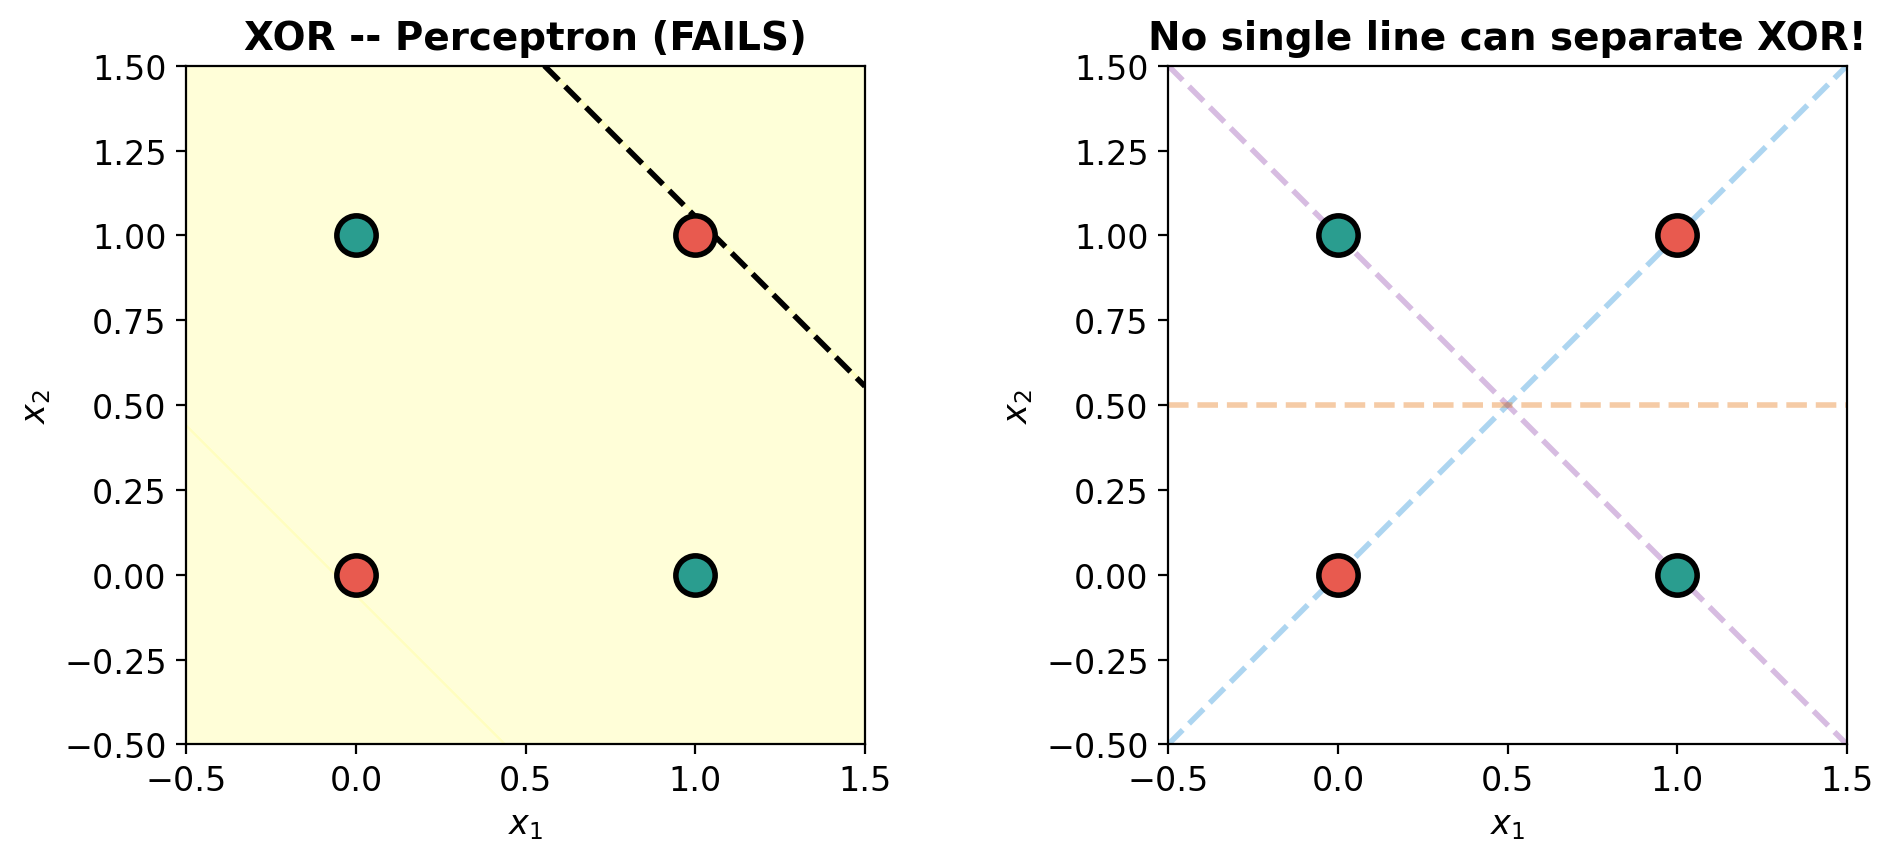

XOR is NOT linearly separable.
No matter what w1, w2, b you pick, one line cannot do it.


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

plot_decision_surface(model_xor, X_gate.numpy(), gates['XOR'], 
                      'XOR -- Perceptron (FAILS)', ax=axes[0])

# Show WHY it fails -- the 4 points with no valid line
ax = axes[1]
y_xor = gates['XOR'].numpy().ravel()
ax.scatter(X_gate[y_xor == 0, 0], X_gate[y_xor == 0, 1], c=C0, s=200,
           edgecolors='black', linewidth=2, zorder=5)
ax.scatter(X_gate[y_xor == 1, 0], X_gate[y_xor == 1, 1], c=C1, s=200,
           edgecolors='black', linewidth=2, zorder=5)

for i in range(4):
    ax.annotate(f'{int(y_xor[i])}', (X_gate[i, 0].item(), X_gate[i, 1].item()),
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Try drawing some lines
x_line = np.linspace(-0.5, 1.5, 100)
for slope, intercept, color in [(1, 0, '#3498db'), (-1, 1, '#9b59b6'), (0, 0.5, '#e67e22')]:
    ax.plot(x_line, slope * x_line + intercept, color=color, alpha=0.4, linewidth=2, linestyle='--')

ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('No single line can separate XOR!', fontweight='bold', fontsize=14)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('XOR is NOT linearly separable.')
print('No matter what w1, w2, b you pick, one line cannot do it.')

## The Fix: Add More Neurons (MLP)

One neuron = one line. **Two neurons = two lines.** Combine them and XOR is solved.

In [39]:
# MLP with one hidden layer (2 hidden neurons)
torch.manual_seed(42)
mlp_xor = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(mlp_xor.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

losses = []
for epoch in range(2000):
    pred = mlp_xor(X_gate)
    loss = loss_fn(pred, gates['XOR'])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

with torch.no_grad():
    preds = mlp_xor(X_gate)

print('MLP predictions for XOR:')
for i in range(4):
    x1, x2 = int(X_gate[i, 0]), int(X_gate[i, 1])
    p = preds[i].item()
    target = int(gates['XOR'][i].item())
    print(f'  {x1} XOR {x2} = {p:.3f} (round to {round(p)}) -- target: {target}')

print('\nThe MLP solves XOR!')

MLP predictions for XOR:
  0 XOR 0 = 0.000 (round to 0) -- target: 0
  0 XOR 1 = 1.000 (round to 1) -- target: 1
  1 XOR 0 = 0.999 (round to 1) -- target: 1
  1 XOR 1 = 0.000 (round to 0) -- target: 0

The MLP solves XOR!


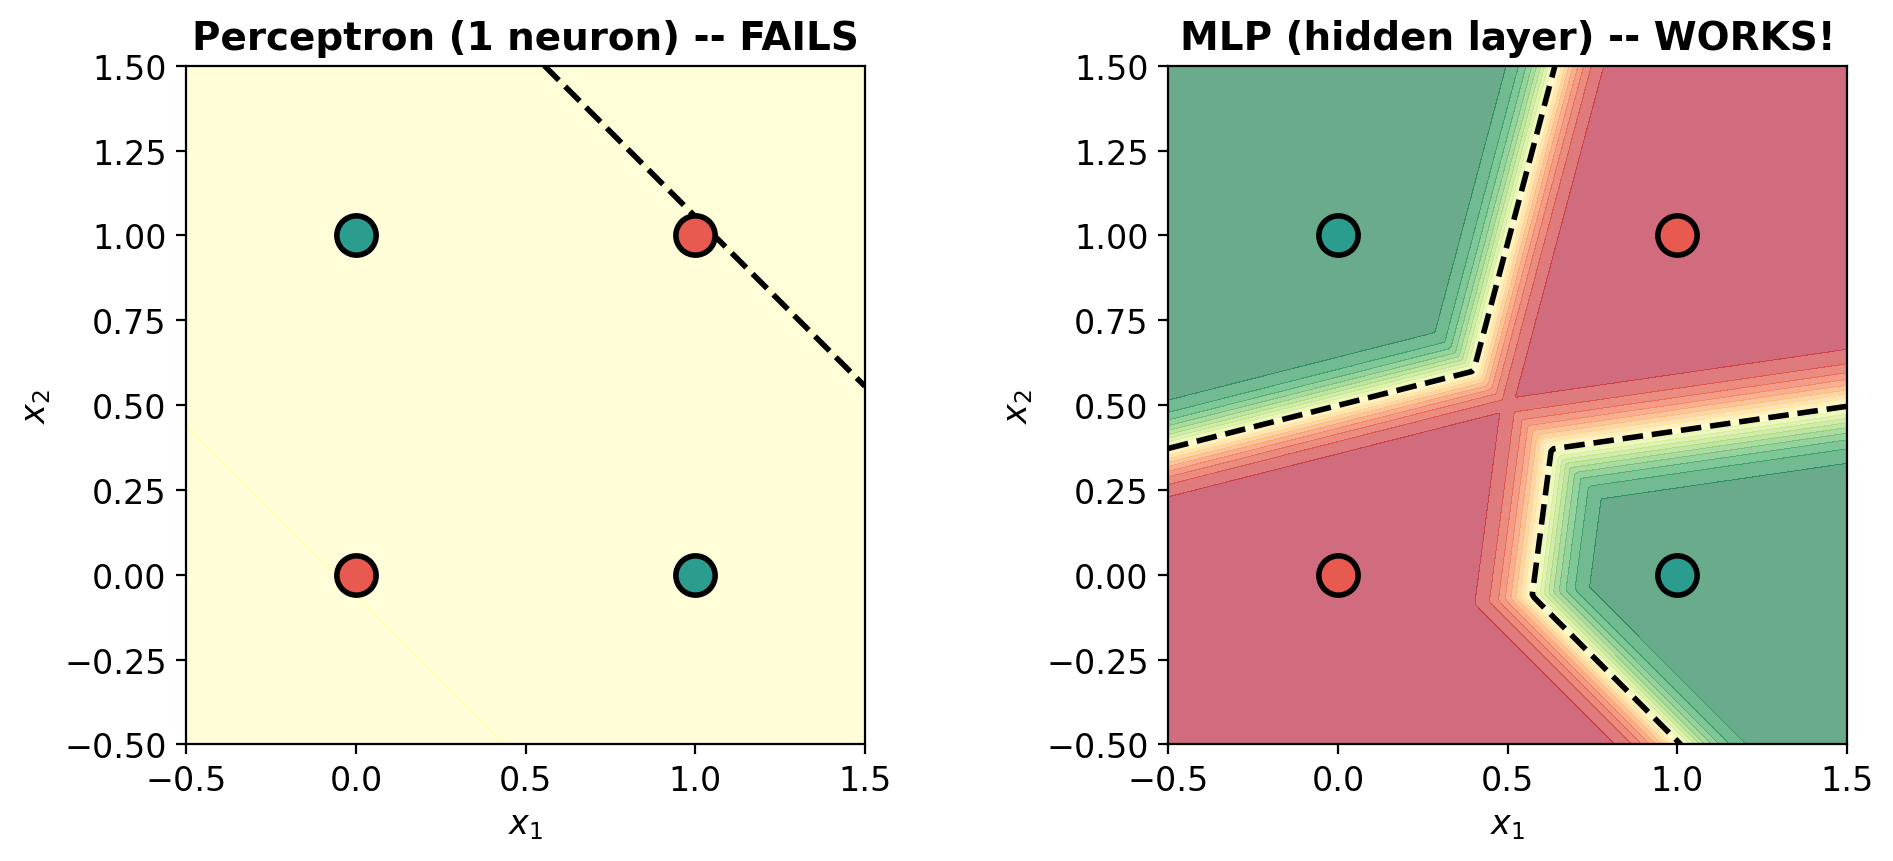

One neuron draws one line. Multiple neurons draw multiple lines.
This is why we need hidden layers!


In [40]:
# Side by side: Perceptron vs MLP on XOR
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

plot_decision_surface(model_xor, X_gate.numpy(), gates['XOR'],
                      'Perceptron (1 neuron) -- FAILS', ax=axes[0])

# MLP decision surface
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = mlp_xor(grid).numpy().reshape(xx.shape)

ax = axes[1]
ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.6, vmin=0, vmax=1)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
y_xor = gates['XOR'].numpy().ravel()
ax.scatter(X_gate[y_xor == 0, 0], X_gate[y_xor == 0, 1], c=C0, s=200,
           edgecolors='black', linewidth=2, zorder=5)
ax.scatter(X_gate[y_xor == 1, 0], X_gate[y_xor == 1, 1], c=C1, s=200,
           edgecolors='black', linewidth=2, zorder=5)
for i in range(4):
    ax.annotate(f'{int(y_xor[i])}', (X_gate[i, 0].item(), X_gate[i, 1].item()),
                ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('MLP (hidden layer) -- WORKS!', fontweight='bold', fontsize=14)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('One neuron draws one line. Multiple neurons draw multiple lines.')
print('This is why we need hidden layers!')

## Watching the Decision Boundary Evolve

Let's watch learning happen in real-time -- how the decision boundary moves during training.

First for the **AND gate** (perceptron), then for **XOR** (MLP).

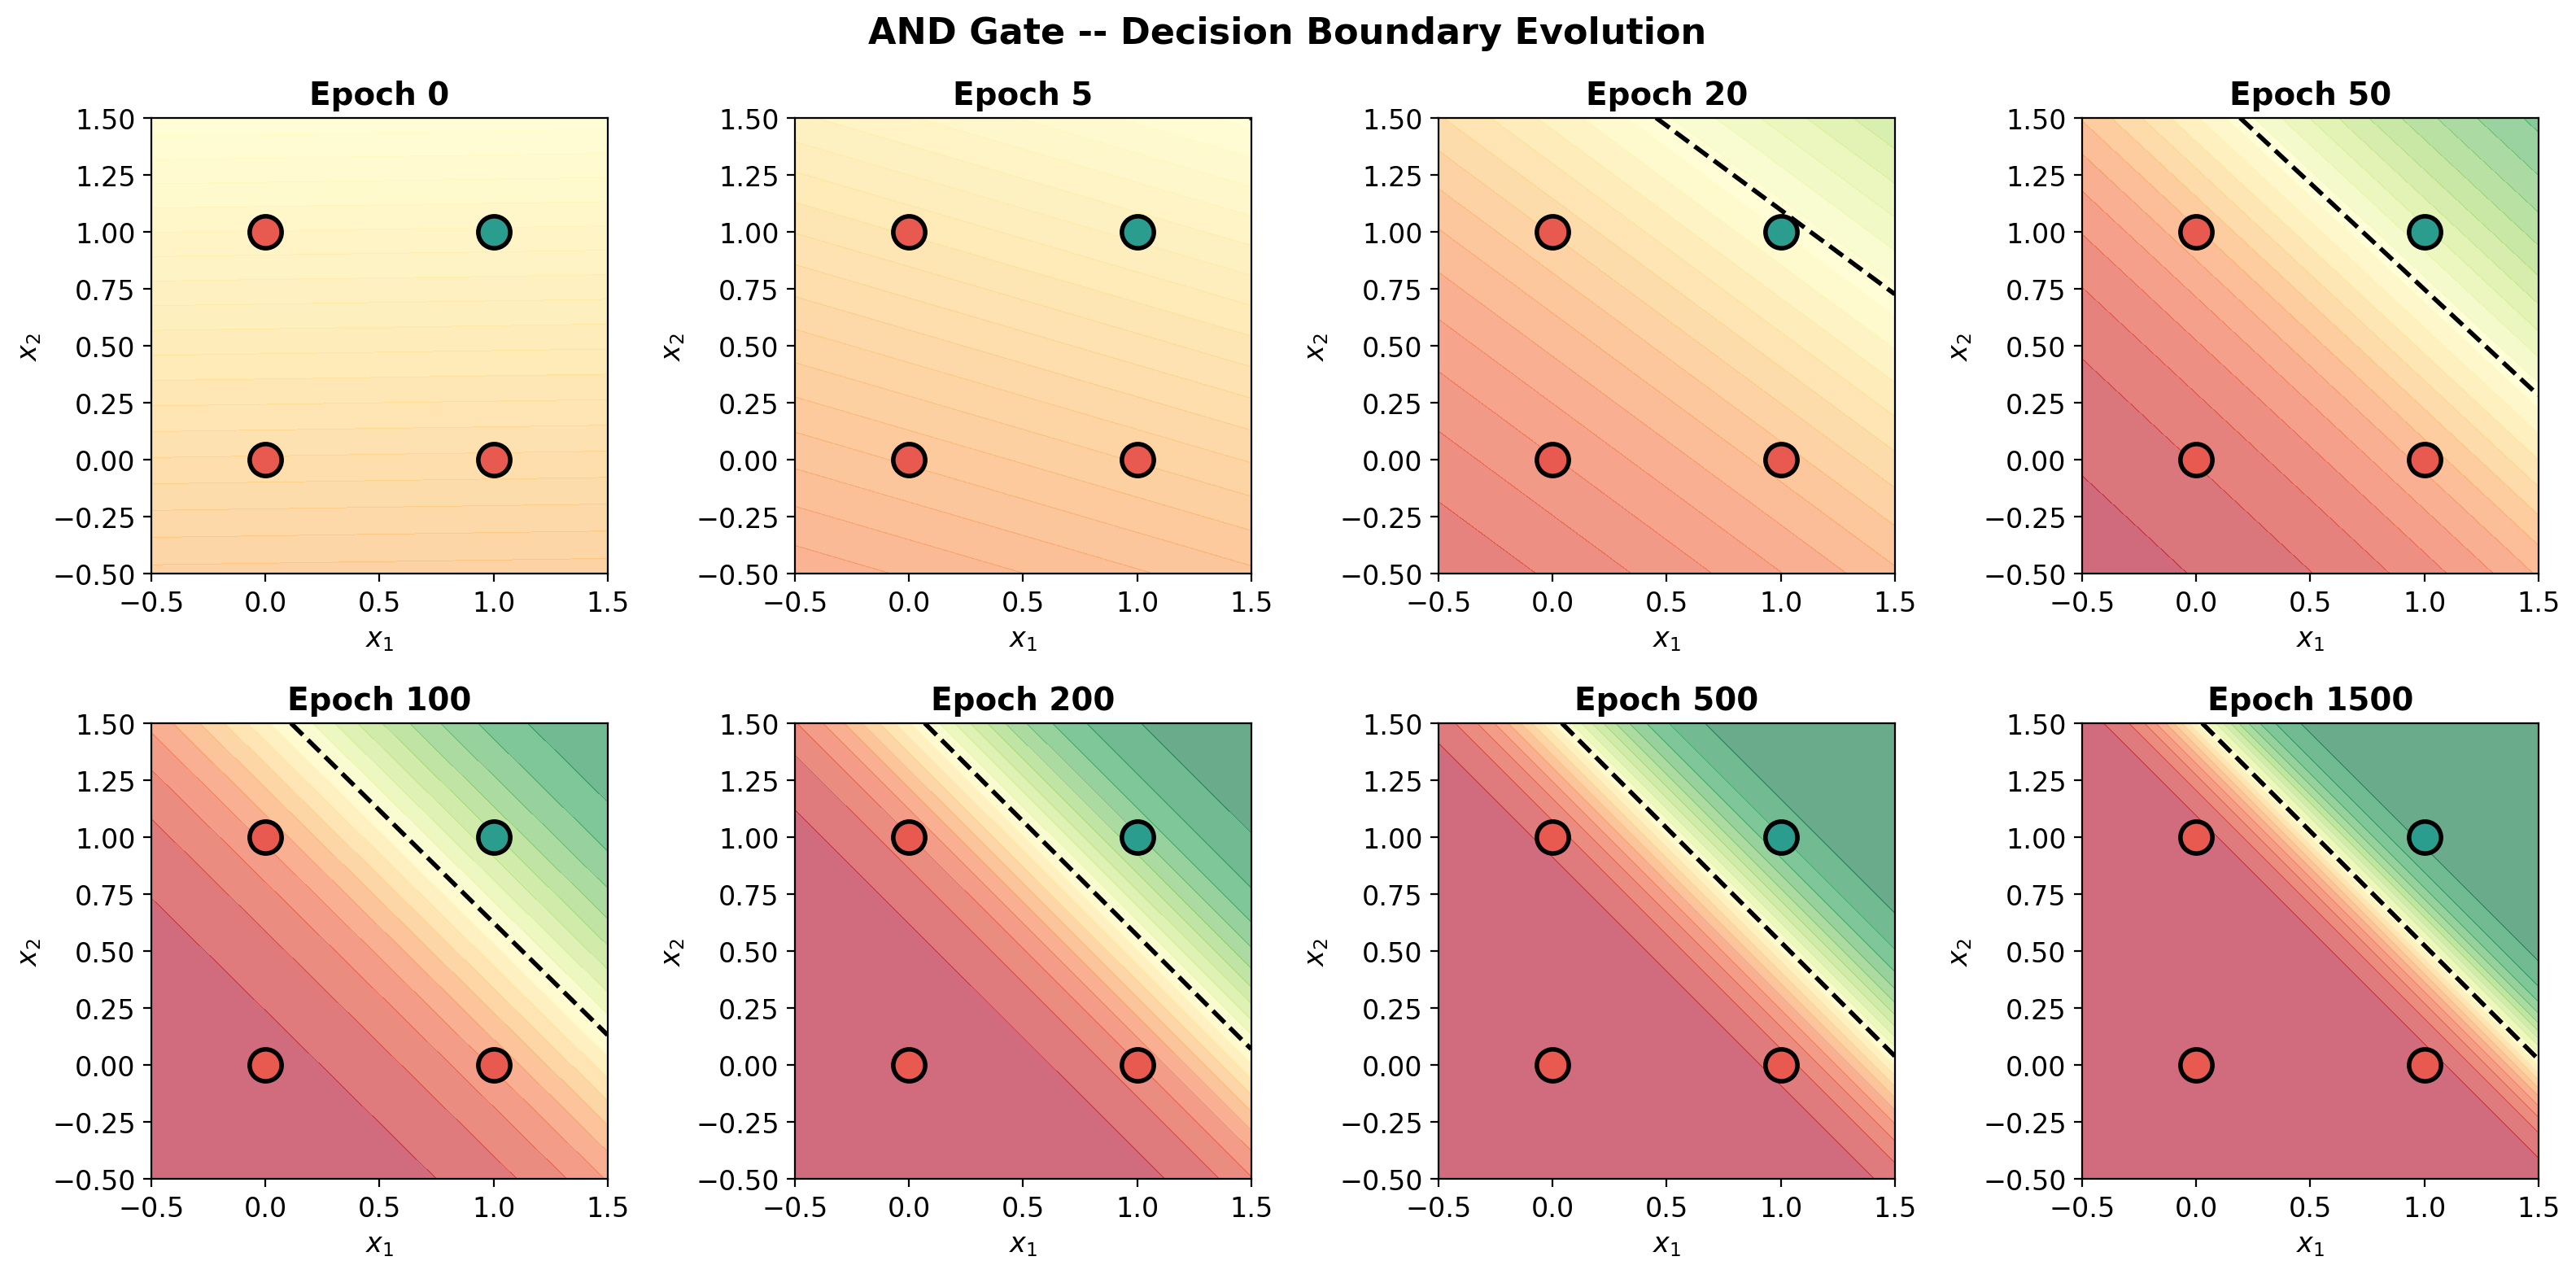

The line starts random and gradually moves to separate the classes.
This is gradient descent in action!


In [41]:
# Train AND gate and capture snapshots
torch.manual_seed(0)
model_anim = Perceptron()
optimizer = optim.SGD(model_anim.parameters(), lr=0.5)
loss_fn = nn.BCELoss()

snapshots = []
snapshot_epochs = [0, 5, 20, 50, 100, 200, 500, 1500]

for epoch in range(1501):
    if epoch in snapshot_epochs:
        # Save a snapshot
        snapshots.append({
            'epoch': epoch,
            'w': model_anim.linear.weight.data.clone(),
            'b': model_anim.linear.bias.data.clone(),
            'state': {k: v.clone() for k, v in model_anim.state_dict().items()}
        })
    
    pred = model_anim(X_gate)
    loss = loss_fn(pred, gates['AND'])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Plot snapshots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, snap in enumerate(snapshots):
    ax = axes[idx]
    
    # Load snapshot weights
    temp_model = Perceptron()
    temp_model.load_state_dict(snap['state'])
    
    plot_decision_surface(temp_model, X_gate.numpy(), gates['AND'],
                          f'Epoch {snap["epoch"]}', ax=ax)

plt.suptitle('AND Gate -- Decision Boundary Evolution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('The line starts random and gradually moves to separate the classes.')
print('This is gradient descent in action!')

### XOR with MLP -- Watch the Boundary Become Non-Linear

The MLP learns to draw a **curved** boundary that separates XOR. Watch it evolve from random to correct.

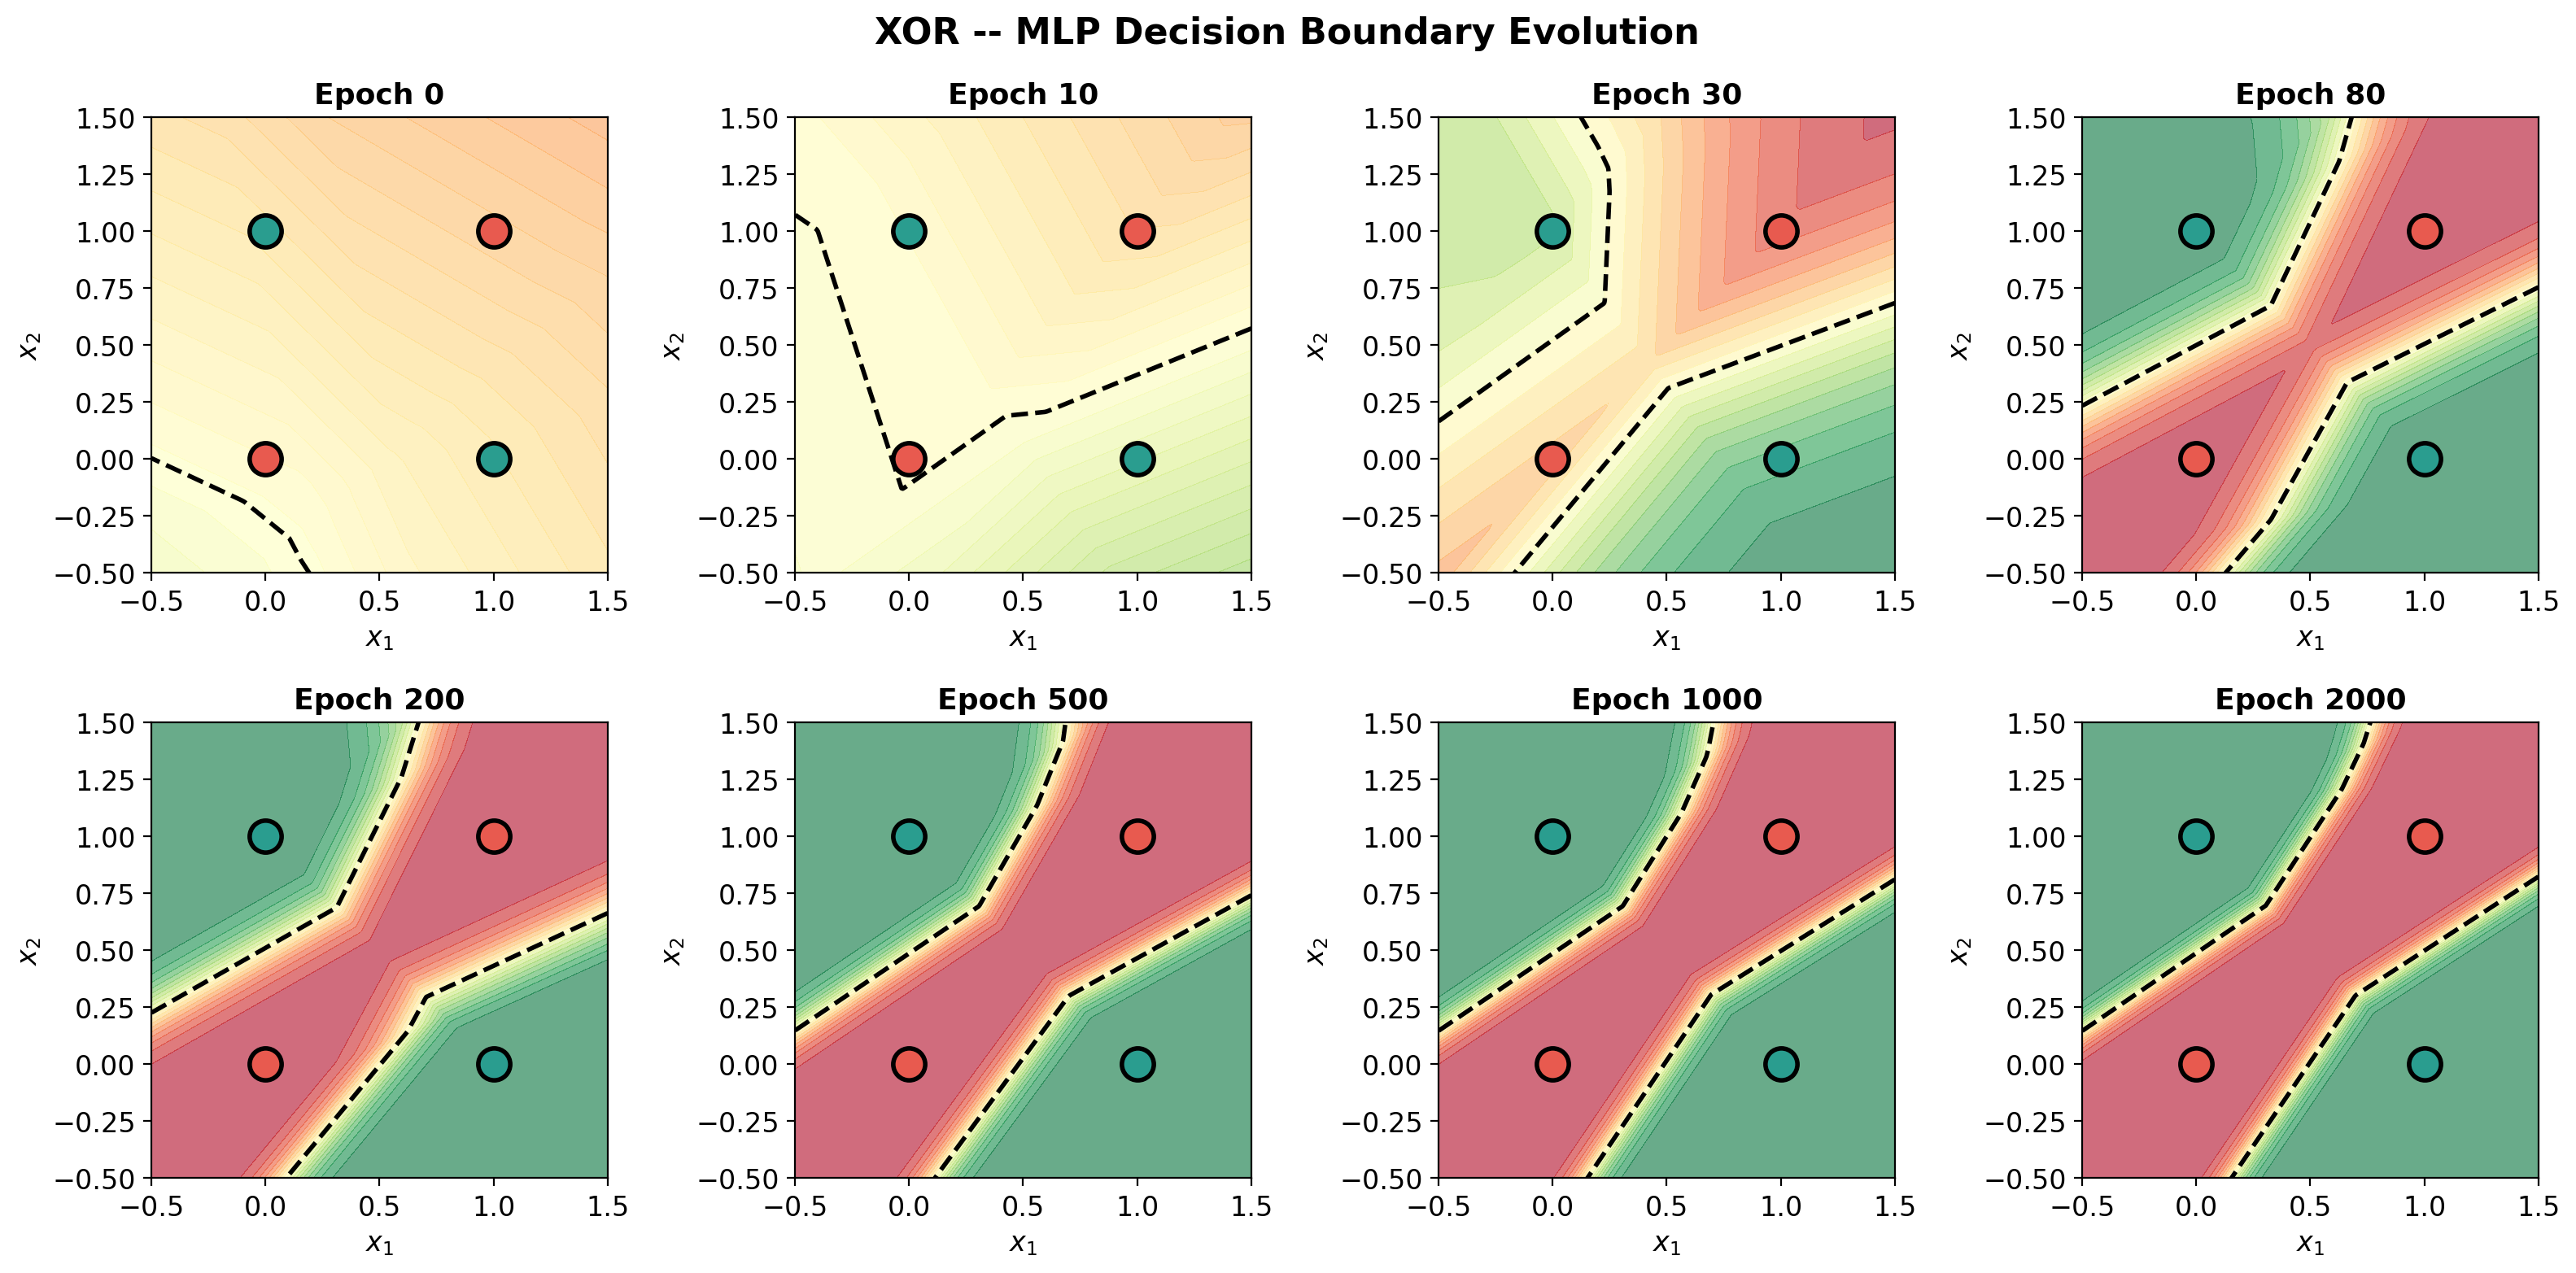

The boundary starts as a simple line (random weights).
Gradually it bends and curves to separate the diagonal points.
This is the hidden layer learning a non-linear transformation!


In [42]:
# Train MLP on XOR and capture snapshots
torch.manual_seed(42)
mlp_anim = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(mlp_anim.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

mlp_snapshots = []
mlp_snapshot_epochs = [0, 10, 30, 80, 200, 500, 1000, 2000]

for epoch in range(2001):
    if epoch in mlp_snapshot_epochs:
        mlp_snapshots.append({
            'epoch': epoch,
            'state': {k: v.clone() for k, v in mlp_anim.state_dict().items()}
        })
    
    pred = mlp_anim(X_gate)
    loss = loss_fn(pred, gates['XOR'])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Plot snapshots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.ravel()

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid_t = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
y_xor = gates['XOR'].numpy().ravel()

for idx, snap in enumerate(mlp_snapshots):
    ax = axes_flat[idx]
    
    # Load snapshot
    temp_mlp = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    temp_mlp.load_state_dict(snap['state'])
    
    with torch.no_grad():
        Z = temp_mlp(grid_t).numpy().reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=0.6, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    ax.scatter(X_gate[y_xor == 0, 0], X_gate[y_xor == 0, 1], c=C0, s=200,
               edgecolors='black', linewidth=2, zorder=5)
    ax.scatter(X_gate[y_xor == 1, 0], X_gate[y_xor == 1, 1], c=C1, s=200,
               edgecolors='black', linewidth=2, zorder=5)
    for i in range(4):
        ax.annotate(f'{int(y_xor[i])}', (X_gate[i, 0].item(), X_gate[i, 1].item()),
                    ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(f'Epoch {snap["epoch"]}', fontweight='bold', fontsize=13)
    ax.set_aspect('equal')

plt.suptitle('XOR -- MLP Decision Boundary Evolution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('The boundary starts as a simple line (random weights).')
print('Gradually it bends and curves to separate the diagonal points.')
print('This is the hidden layer learning a non-linear transformation!')

## Summary

| Gate | Linearly Separable? | Perceptron Learns It? |
|------|--------------------|-----------------------|
| AND  | Yes | Yes |
| OR   | Yes | Yes |
| NAND | Yes | Yes |
| XOR  | **No** | **No** |

**Key lessons:**
1. A perceptron = one neuron = one straight line
2. It learns by adjusting $w_1, w_2, b$ to minimize loss (gradient descent)
3. If data is linearly separable, the perceptron will find the line
4. XOR is NOT linearly separable -- you need **multiple neurons** (an MLP)
5. This is why neural networks have **hidden layers**

Minsky & Papert showed this limitation in 1969. It took until the 1980s (backpropagation) to train multi-layer networks effectively.